# CROCUS RG-15 Data Quality Analysis

Investigation of artifact signals in the Hydreon RG-15 optical rain gauge
data across CROCUS sites. All analysis uses the RG-15 + WXT cross-validation
framework developed in `crocus_precip.ipynb` — run that notebook first to
populate `rain`, `wxt_rain`, `rg_hourly`, and `wxt_hourly` in scope.

## Findings summary

| Site | Issue | Status |
|---|---|---|
| UIC (W096) | Solar interference artifact at solar noon | Confirmed — software flag pending |
| CSU (W08E) | Solar interference — more severe than UIC | Confirmed — physical inspection recommended |
| HUM (W0A1) | RG-15 silent since ~April 2026 | RPi reboot needed |
| NEIU (W08D) | RG-15 silent — RPi inactive | RPi reboot needed |

## Analysis sequence
1. Time-of-day histogram and scatter — identifies when artifacts occur
2. FFT power spectrum — tests for fixed periodicity (inconclusive for solar artifacts)
3. Diurnal heatmap (hour × date) — visually confirms solar noon signature
4. Solar position heatmap (azimuth × elevation) — maps artifact to sun geometry

In [14]:
# Standard library
import ssl

# Third party
import matplotlib.pyplot as plt
import pandas as pd

# Local
import importlib
import crocus_sites
importlib.reload(crocus_sites)
import sage_utils
importlib.reload(sage_utils)
import crocus_precip
importlib.reload(crocus_precip)

from crocus_sites import (
    ALL_SITES,
    ATMOS, BIG, CCICS, CSU,
    HUM, NEIU, NU, SHEDD, UIC,
)
from sage_utils import query_wxt, last_n_hours
from crocus_precip import query_raingauge, query_asos, query_cocorahs

ssl._create_default_https_context = ssl._create_unverified_context


In [15]:
SITE = UIC
START = "2026-03-01"
END   = "2026-05-26"


In [16]:
WXT_RESAMPLE = "5min"

# Query RG-15 and WXT
rain = query_raingauge(SITE, START, END) if SITE.has_raingauge else pd.DataFrame()

wxt_rain = pd.DataFrame()
if SITE.has_wxt:
    wxt_rain = query_wxt(SITE, START, END, resample=WXT_RESAMPLE)

has_wxt_rain = (
    not wxt_rain.empty
    and "rain" in wxt_rain.columns
    and wxt_rain["rain"].notna().any()
)

if has_wxt_rain:
    interval_minutes = pd.tseries.frequencies.to_offset(WXT_RESAMPLE).nanos / 6e10
    wxt_rain["rain_rate"] = (
        wxt_rain["rain"]
        .diff()
        .clip(lower=0)
        / (interval_minutes / 60)
    )

# Hourly accumulations used by all analysis cells below
rg_hourly = (
    rain['event_acc']
    .resample('1h').max()
    .diff()
    .clip(lower=0)
) if not rain.empty else pd.Series(dtype=float)

wxt_hourly = (
    wxt_rain['rain']
    .resample('1h').max()
    .diff()
    .clip(lower=0)
) if has_wxt_rain else pd.Series(dtype=float)

# Artifact thresholds used by Cells 5 and 7
rg_threshold = 0.1   # mm — any measurable hourly acc
rg_max       = 3.0   # mm — cap to focus on light events only

print(f"Site:          {SITE.abbr} ({SITE.vsn})")
print(f"Window:        {START} to {END}")
print(f"RG-15 records: {len(rain)}")
print(f"WXT records:   {len(wxt_rain)}")

Site:          UIC (W096)
Window:        2026-03-01 to 2026-05-26
RG-15 records: 228923
WXT records:   22242


## FFT Power Spectrum Analysis

Spectral analysis of the RG-15 hourly accumulation time series to test for
fixed periodicity. A mechanical or anthropogenic artifact source would produce
a sharp spike at its characteristic frequency. Natural precipitation produces
broad red-noise structure with possible peaks at meteorological timescales
(24-hour diurnal, 3-7 day synoptic).

**Finding at UIC and CSU:** The 24-hour diurnal peak dominates the spectrum,
but this is inconclusive — a solar noon artifact occurs at exactly the same
frequency as natural diurnal precipitation and cannot be separated by FFT alone.
The heatmap analysis (below) is required to distinguish them.

Signal length: 2064
NaNs in signal: 0
Non-zero values: 2064


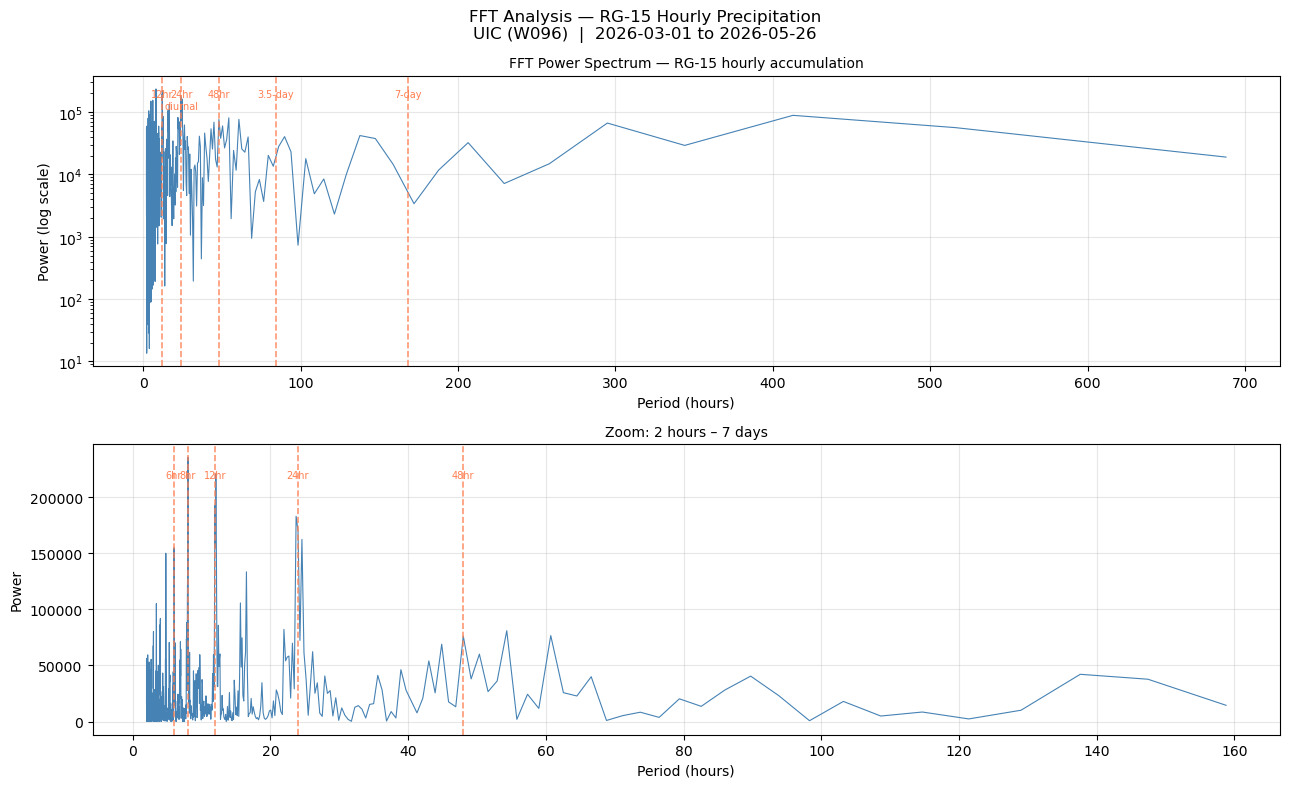


Top 10 periods by power:
       8.0 hrs  (0.33 days)  power=235486.5
      12.1 hrs  (0.50 days)  power=220725.1
       8.0 hrs  (0.33 days)  power=216788.6
      11.9 hrs  (0.50 days)  power=192660.2
      23.7 hrs  (0.99 days)  power=182922.4
      24.0 hrs  (1.00 days)  power=170301.3
      24.6 hrs  (1.02 days)  power=162295.7
      12.1 hrs  (0.51 days)  power=159297.4
       6.0 hrs  (0.25 days)  power=154930.0
      12.0 hrs  (0.50 days)  power=154750.6


In [17]:
import numpy as np

# Use the full rg_hourly series reindexed to a complete hourly grid
# FFT requires evenly spaced data — fill missing hours with 0
rg_full = rg_hourly.reindex(
    pd.date_range(rg_hourly.index.min(), rg_hourly.index.max(), freq='1h', tz='UTC'),
    fill_value=0.0
).fillna(0.0)   # catch any remaining NaNs from diff()

# Detrend by subtracting mean
signal = rg_full.values - rg_full.values.mean()

print(f"Signal length: {len(signal)}")
print(f"NaNs in signal: {np.isnan(signal).sum()}")
print(f"Non-zero values: {(signal != 0).sum()}")

# Compute FFT
n     = len(signal)
fft   = np.fft.rfft(signal)
freq  = np.fft.rfftfreq(n, d=1.0)   # cycles per hour
power = np.abs(fft) ** 2

# Convert frequency to period in hours — avoid divide-by-zero at freq=0
with np.errstate(divide='ignore', invalid='ignore'):
    period_hours = np.where(freq > 0, 1.0 / freq, np.inf)

# Focus on periods between 2 hours and 30 days
mask      = (period_hours >= 2) & (period_hours <= 24 * 30)
mask_zoom = (period_hours >= 2) & (period_hours <= 24 * 7)

fig, axes = plt.subplots(2, 1, figsize=(13, 8))

# --- Panel 1: Full power spectrum (log scale) ---
axes[0].semilogy(period_hours[mask], power[mask],
                 color='steelblue', linewidth=0.8)
axes[0].set_xlabel('Period (hours)')
axes[0].set_ylabel('Power (log scale)')
axes[0].set_title('FFT Power Spectrum — RG-15 hourly accumulation', fontsize=10)
axes[0].grid(True, alpha=0.3)

for p, label in [(24, '24hr\ndiurnal'), (12, '12hr'), (48, '48hr'),
                 (24*7, '7-day'), (24*3.5, '3.5-day')]:
    axes[0].axvline(p, color='coral', linewidth=1.2, linestyle='--', alpha=0.8)
    axes[0].text(p, power[mask].max(), label,
                 fontsize=7, color='coral', ha='center', va='top')

# --- Panel 2: Zoom into sub-weekly periods ---
axes[1].plot(period_hours[mask_zoom], power[mask_zoom],
             color='steelblue', linewidth=0.8)
axes[1].set_xlabel('Period (hours)')
axes[1].set_ylabel('Power')
axes[1].set_title('Zoom: 2 hours – 7 days', fontsize=10)
axes[1].grid(True, alpha=0.3)

for p, label in [(24, '24hr'), (12, '12hr'), (8, '8hr'),
                 (6, '6hr'), (48, '48hr')]:
    axes[1].axvline(p, color='coral', linewidth=1.2, linestyle='--', alpha=0.8)
    axes[1].text(p, power[mask_zoom].max() * 0.95, label,
                 fontsize=7, color='coral', ha='center', va='top')

fig.suptitle(
    f'FFT Analysis — RG-15 Hourly Precipitation\n'
    f'{SITE.abbr} ({SITE.vsn})  |  {START} to {END}',
    fontsize=12
)
fig.tight_layout()
plt.savefig(f"figures/{SITE.abbr}_precip_fft.png", dpi=150, bbox_inches='tight')
plt.show()

# Print top 10 periods by power
top_idx = np.argsort(power[mask])[::-1][:10]
print("\nTop 10 periods by power:")
for i in top_idx:
    idx = np.where(mask)[0][i]
    print(f"  {period_hours[idx]:8.1f} hrs  ({period_hours[idx]/24:.2f} days)  "
          f"power={power[idx]:.1f}")

## Time-of-Day Distribution

Histogram and scatter plot of light RG-15 events (≤3 mm/hr hourly accumulation)
by local time of day. Solar interference artifacts would cluster near solar noon
(~12:48 CDT in Chicago spring). Dew or condensation artifacts would cluster near
sunrise. Random sensor noise or missed light rain would be uniformly distributed.

Sunrise, solar noon, and sunset are computed from `pvlib` for the actual
site coordinates and date window rather than hardcoded approximations.

Mean sunrise:    6.23 CDT
Mean solar noon: 12.80 CDT
Mean sunset:     19.37 CDT


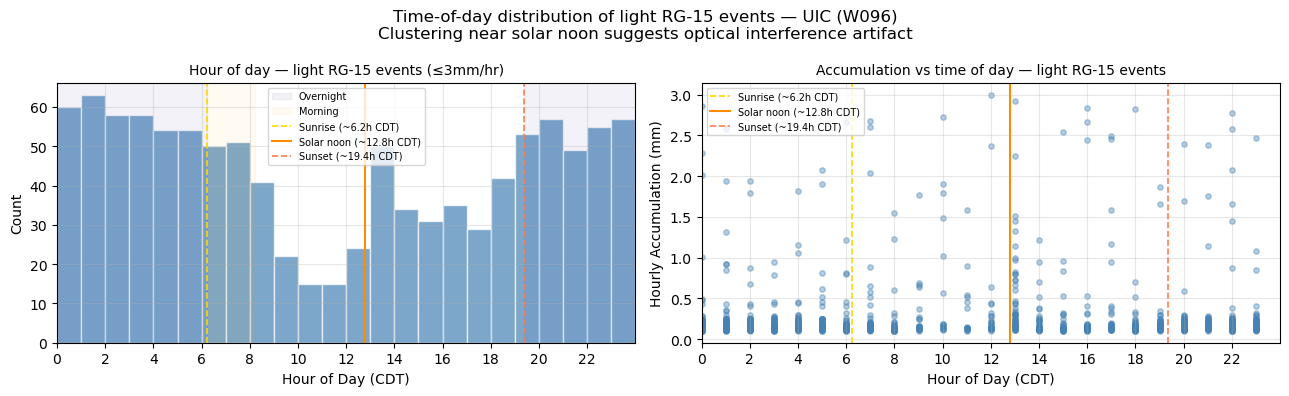


Total candidate events: 1057
Median hour (CDT):      11.0
Mean accumulation:      0.30 mm


In [18]:
import pvlib

# Isolate RG-15-only low-intensity events (candidate solar artifacts)
rg_threshold = 0.1   # mm — any measurable hourly acc
rg_max       = 3.0   # mm — cap to focus on light events only

rg_cand = rg_hourly[
    (rg_hourly > rg_threshold) &
    (rg_hourly <= rg_max)
]

# Convert UTC index to local CDT for interpretable time-of-day
rg_cand_local = rg_cand.copy()
rg_cand_local.index = rg_cand.index.tz_convert('America/Chicago')
hour_of_day = rg_cand_local.index.hour + rg_cand_local.index.minute / 60

# Compute mean sunrise, solar noon, sunset over the data window
try:
    lat, lon = SITE.lat, SITE.lon
except AttributeError:
    lat, lon = 41.8708, -87.6505

date_range = pd.date_range(
    pd.to_datetime(START, utc=True).date(),
    pd.to_datetime(END,   utc=True).date(),
    freq='D', tz='UTC'
)

sunrise_hours    = []
solar_noon_hours = []
sunset_hours     = []

for date in date_range:
    # Start from local midnight to avoid UTC/CDT day boundary wraparound
    local_midnight = pd.Timestamp(str(date.date()), tz='America/Chicago')
    times = pd.date_range(local_midnight, periods=1440, freq='1min').tz_convert('UTC')
    sp    = pvlib.solarposition.get_solarposition(times, lat, lon)
    elev  = sp['apparent_elevation']

    times_cdt  = times.tz_convert('America/Chicago')
    noon_cdt   = times_cdt[elev.values.argmax()]
    above_zero = elev[elev > 0]

    if len(above_zero) > 1:
        rise_pos = elev.index.get_loc(above_zero.index[0])
        set_pos  = elev.index.get_loc(above_zero.index[-1])
        rise_cdt = times_cdt[rise_pos]
        set_cdt  = times_cdt[set_pos]
        sunrise_hours.append(rise_cdt.hour + rise_cdt.minute / 60)
        sunset_hours.append(set_cdt.hour   + set_cdt.minute  / 60)

    solar_noon_hours.append(noon_cdt.hour + noon_cdt.minute / 60)

mean_sunrise    = pd.Series(sunrise_hours).mean()
mean_solar_noon = pd.Series(solar_noon_hours).mean()
mean_sunset     = pd.Series(sunset_hours).mean()

print(f"Mean sunrise:    {mean_sunrise:.2f} CDT")
print(f"Mean solar noon: {mean_solar_noon:.2f} CDT")
print(f"Mean sunset:     {mean_sunset:.2f} CDT")

# --- Plot ---
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Panel 1: Histogram
axes[0].hist(hour_of_day, bins=24, range=(0, 24),
             color='steelblue', alpha=0.7, edgecolor='white')
axes[0].set_xlabel('Hour of Day (CDT)')
axes[0].set_ylabel('Count')
axes[0].set_xticks(range(0, 24, 2))
axes[0].set_xlim(0, 24)
axes[0].axvspan(0, mean_sunrise,
                alpha=0.05, color='navy',   label='Overnight')
axes[0].axvspan(mean_sunrise, mean_sunrise + 2,
                alpha=0.05, color='orange', label='Morning')
axes[0].axvspan(mean_sunset, 24,
                alpha=0.05, color='navy')
axes[0].grid(True, alpha=0.3)
axes[0].set_title('Hour of day — light RG-15 events (≤3mm/hr)', fontsize=10)

# Panel 2: Scatter
axes[1].scatter(hour_of_day, rg_cand_local.values,
                color='steelblue', alpha=0.4, s=15)
axes[1].set_xlabel('Hour of Day (CDT)')
axes[1].set_ylabel('Hourly Accumulation (mm)')
axes[1].set_xticks(range(0, 24, 2))
axes[1].set_xlim(0, 24)
axes[1].grid(True, alpha=0.3)
axes[1].set_title('Accumulation vs time of day — light RG-15 events', fontsize=10)

# Overlay sunrise, solar noon, sunset on both panels
for ax in axes:
    ax.axvline(mean_sunrise,    color='gold',      linewidth=1.2,
               linestyle='--', label=f'Sunrise (~{mean_sunrise:.1f}h CDT)')
    ax.axvline(mean_solar_noon, color='darkorange', linewidth=1.5,
               linestyle='-',  label=f'Solar noon (~{mean_solar_noon:.1f}h CDT)')
    ax.axvline(mean_sunset,     color='coral',     linewidth=1.2,
               linestyle='--', label=f'Sunset (~{mean_sunset:.1f}h CDT)')
    ax.legend(fontsize=7)

fig.suptitle(
    f'Time-of-day distribution of light RG-15 events — {SITE.abbr} ({SITE.vsn})\n'
    f'Clustering near solar noon suggests optical interference artifact',
    fontsize=12
)
fig.tight_layout()
plt.savefig(f"figures/{SITE.abbr}_artifact_timing.png",
            dpi=150, bbox_inches='tight')
plt.show()

print(f"\nTotal candidate events: {len(rg_cand)}")
print(f"Median hour (CDT):      {pd.Series(hour_of_day).median():.1f}")
print(f"Mean accumulation:      {rg_cand.mean():.2f} mm")

## Diurnal Precipitation Heatmap

Hour-of-day × date heatmap for RG-15 and WXT hourly accumulation over the
full analysis window. This visualization preserves both the time-of-day and
date dimensions that the FFT collapses — making it the most diagnostic tool
for solar interference artifacts.

**What to look for:**
- A horizontal stripe at a fixed hour across many days → systematic artifact
- Discrete vertical streaks scattered across all hours → real rain events
- Stripe present in RG-15 but absent in WXT → RG-15-specific artifact

**Finding at UIC and CSU:** A clear horizontal band at 12:00–13:00 CDT
(solar noon) is visible in the RG-15 panel but completely absent in the WXT
panel, confirming solar optical interference in the RG-15.

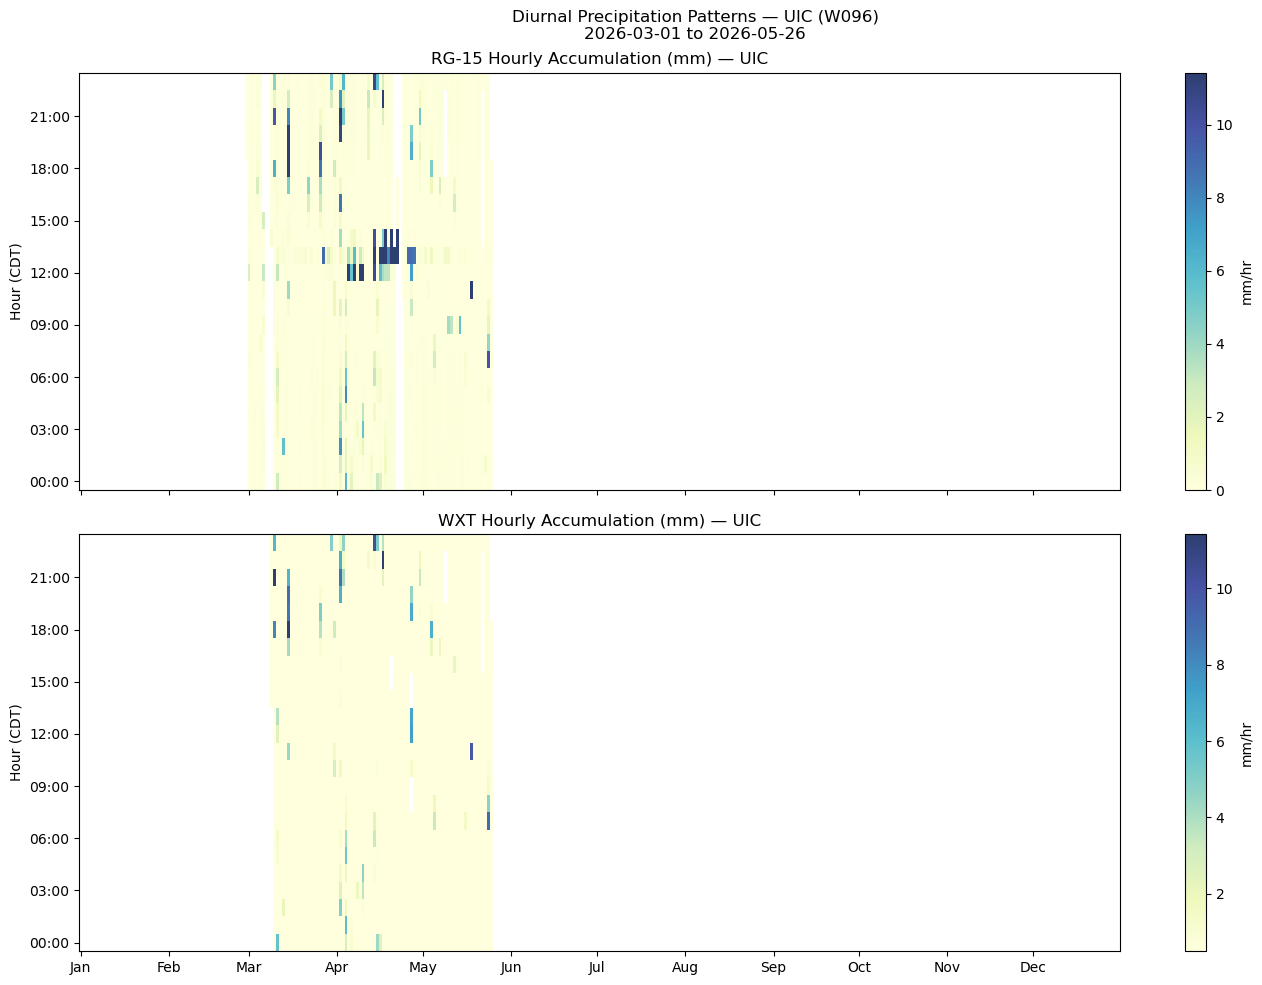

In [19]:
import sys
sys.path.append('../air_quality')
from plot_time_heatmap import plot_time_heatmap

# Prepare RG-15 and WXT as DataFrames with local time index
def _to_local_df(series, col_name):
    df = series.to_frame(name=col_name)
    df.index = df.index.tz_convert('America/Chicago')
    return df.dropna()

rg_hm  = _to_local_df(rg_hourly,  'precip_mm')
wxt_hm = _to_local_df(wxt_hourly, 'precip_mm') if has_wxt_rain else None

# Common scale across both panels
vmax = max(
    rg_hm['precip_mm'].quantile(0.99) if not rg_hm.empty else 0,
    wxt_hm['precip_mm'].quantile(0.99) if wxt_hm is not None and not wxt_hm.empty else 0,
)

nrows = 2 if wxt_hm is not None and not wxt_hm.empty else 1
fig, axes = plt.subplots(nrows, 1, figsize=(14, 5 * nrows), sharex=True)
if nrows == 1:
    axes = [axes]

plot_time_heatmap(
    rg_hm, datetime_col=None, value_col='precip_mm',
    title=f'RG-15 Hourly Accumulation (mm) — {SITE.abbr}',
    ylabel='Hour (CDT)',
    colorbar_label='mm/hr',
    cmap='YlGnBu',
    vmin=0, vmax=vmax,
    ax=axes[0]
)

if wxt_hm is not None and not wxt_hm.empty:
    plot_time_heatmap(
        wxt_hm, datetime_col=None, value_col='precip_mm',
        title=f'WXT Hourly Accumulation (mm) — {SITE.abbr}',
        ylabel='Hour (CDT)',
        colorbar_label='mm/hr',
        cmap='YlGnBu',
        vmin=0.5, vmax=vmax,
        ax=axes[1]
    )

fig.suptitle(
    f'Diurnal Precipitation Patterns — {SITE.abbr} ({SITE.vsn})\n'
    f'{START} to {END}',
    fontsize=12
)
fig.tight_layout()
plt.savefig(f"figures/{SITE.abbr}_precip_heatmap.png", dpi=150, bbox_inches='tight')
plt.show()

## Solar Position Heatmap

RG-15 light event accumulation and count mapped onto a solar azimuth ×
elevation grid. Each cell shows the mean hourly accumulation (left) and
event count (right) for all candidate artifact events when the sun was at
that specific position in the sky.

**What to look for:**
- A tight isolated cluster at one azimuth/elevation → fixed geometric
  interference angle (single reflection point or aperture orientation)
- Events distributed along the full solar arc → broadband irradiance
  sensitivity (sensor saturating at high sun angles generally)
- High mean AND high count in the same bin → systematic, not coincidental

**Finding at UIC (W096):** Events are distributed along the full solar arc
from E through SE/S to SW/W with highest density around S at 50–70° elevation
(solar noon in April–May). This indicates broadband solar sensitivity rather
than a single geometric reflection angle.

**Finding at CSU (W08E):** The artifact signal covers a broader range of
solar azimuths than UIC, spanning SE through S to SW at elevations of 50–70°.
This wider footprint in solar position space suggests the CSU sensor has
greater overall exposure to high-elevation sun angles, consistent with the
more severe and continuous artifact band seen in the diurnal heatmap.
Physical inspection of the CSU mounting geometry is recommended.

For both sites, a sunshade is not practical given WXT wind sensor co-location
on the same pole. Software flagging based on solar position is the recommended
near-term mitigation — see findings summary in the notebook header.

In [ ]:
# Run this cell first in Google Colab.
# It is harmless in a normal local Jupyter session.

import os
import sys
from pathlib import Path

IN_COLAB = "COLAB_RELEASE_TAG" in os.environ

if IN_COLAB:
    %cd /content
    !git clone -q https://github.com/gregorywanderson/crocus.git
    %cd /content/crocus
    !pip install -q -r requirements.txt

# Make sure Python can find local modules such as sage_utils.py
# and crocus_sites.py.
if IN_COLAB:
    sys.path.insert(0, "/content/crocus")
else:
    sys.path.insert(0, str(Path.cwd()))

Total candidate events:          1057
Daytime candidate events:        456
Nighttime (excluded):            601


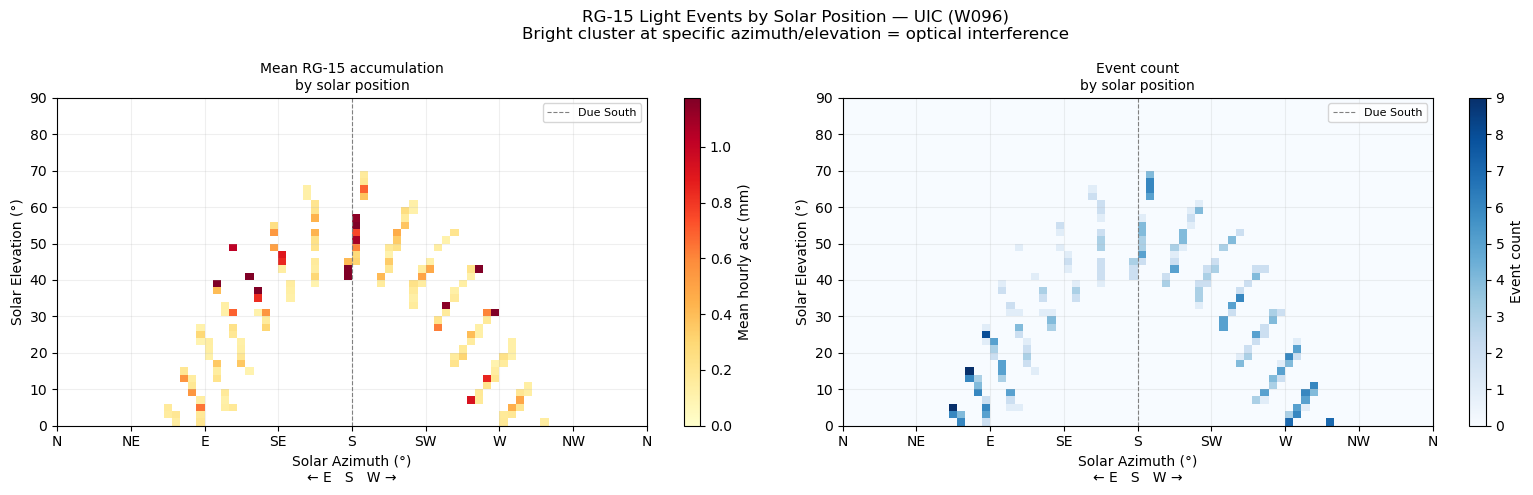


Peak mean accumulation at:
  Azimuth:   115–120° (E)
  Elevation: 40–42°
  Mean acc:  1.79 mm
  Count:     1 events


In [20]:
import pvlib

# --- Get solar position at every RG-15 candidate event timestamp -----------
try:
    lat, lon = SITE.lat, SITE.lon
except AttributeError:
    lat, lon = 41.8708, -87.6505

# Use the full rg_hourly index for solar position
# Filter to candidate artifact events (RG-15 only, light rain)
rg_cand_utc = rg_hourly[
    (rg_hourly > rg_threshold) &
    (rg_hourly <= rg_max)
].dropna()

# Compute solar position at each candidate timestamp
solpos = pvlib.solarposition.get_solarposition(
    rg_cand_utc.index, lat, lon, altitude=179
)

# Only keep daytime events — solar interference requires the sun to be up
daytime = solpos['apparent_elevation'] > 0
solpos_day  = solpos[daytime]
rg_cand_day = rg_cand_utc[daytime]

print(f"Total candidate events:          {len(rg_cand_utc)}")
print(f"Daytime candidate events:        {len(rg_cand_day)}")
print(f"Nighttime (excluded):            {(~daytime).sum()}")

# --- Build azimuth × elevation heatmap -------------------------------------
az_bins  = np.arange(0,   361, 5)    # 5° azimuth bins
el_bins  = np.arange(0,   91,  2)    # 2° elevation bins

# Accumulate mean RG-15 value in each bin
az_idx = np.digitize(solpos_day['azimuth'],          az_bins) - 1
el_idx = np.digitize(solpos_day['apparent_elevation'], el_bins) - 1

grid_sum   = np.zeros((len(el_bins)-1, len(az_bins)-1))
grid_count = np.zeros_like(grid_sum)

for i, (az, el, val) in enumerate(zip(az_idx, el_idx, rg_cand_day.values)):
    if 0 <= az < grid_sum.shape[1] and 0 <= el < grid_sum.shape[0]:
        grid_sum[el, az]   += val
        grid_count[el, az] += 1

# Mean accumulation per bin — NaN where no events
with np.errstate(invalid='ignore'):
    grid_mean = np.where(grid_count > 0, grid_sum / grid_count, np.nan)

# --- Plot ------------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Panel 1: Mean RG-15 accumulation
im1 = axes[0].pcolormesh(
    az_bins, el_bins, grid_mean,
    cmap='YlOrRd', shading='flat',
    vmin=0, vmax=np.nanpercentile(grid_mean, 95)
)
plt.colorbar(im1, ax=axes[0], label='Mean hourly acc (mm)')
axes[0].set_xlabel('Solar Azimuth (°)\n← E   S   W →')
axes[0].set_ylabel('Solar Elevation (°)')
axes[0].set_title('Mean RG-15 accumulation\nby solar position', fontsize=10)
axes[0].set_xlim(0, 360)
axes[0].set_ylim(0, 90)
axes[0].axvline(180, color='0.5', linewidth=0.8, linestyle='--', label='Due South')
axes[0].set_xticks([0, 45, 90, 135, 180, 225, 270, 315, 360])
axes[0].set_xticklabels(['N', 'NE', 'E', 'SE', 'S', 'SW', 'W', 'NW', 'N'])
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.2)

# Panel 2: Event count per bin
im2 = axes[1].pcolormesh(
    az_bins, el_bins, grid_count,
    cmap='Blues', shading='flat'
)
plt.colorbar(im2, ax=axes[1], label='Event count')
axes[1].set_xlabel('Solar Azimuth (°)\n← E   S   W →')
axes[1].set_ylabel('Solar Elevation (°)')
axes[1].set_title('Event count\nby solar position', fontsize=10)
axes[1].set_xlim(0, 360)
axes[1].set_ylim(0, 90)
axes[1].axvline(180, color='0.5', linewidth=0.8, linestyle='--', label='Due South')
axes[1].set_xticks([0, 45, 90, 135, 180, 225, 270, 315, 360])
axes[1].set_xticklabels(['N', 'NE', 'E', 'SE', 'S', 'SW', 'W', 'NW', 'N'])
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.2)

fig.suptitle(
    f'RG-15 Light Events by Solar Position — {SITE.abbr} ({SITE.vsn})\n'
    f'Bright cluster at specific azimuth/elevation = optical interference',
    fontsize=12
)
fig.tight_layout()
plt.savefig(f"figures/{SITE.abbr}_rg15_solar_heatmap.png",
            dpi=150, bbox_inches='tight')
plt.show()

# Print the peak bin
peak = np.unravel_index(np.nanargmax(grid_mean), grid_mean.shape)
print(f"\nPeak mean accumulation at:")
print(f"  Azimuth:   {az_bins[peak[1]]:.0f}–{az_bins[peak[1]+1]:.0f}° "
      f"({['N','NE','E','SE','S','SW','W','NW'][int(peak[1]*5/45) % 8]})")
print(f"  Elevation: {el_bins[peak[0]]:.0f}–{el_bins[peak[0]+1]:.0f}°")
print(f"  Mean acc:  {grid_mean[peak]:.2f} mm")
print(f"  Count:     {grid_count[peak]:.0f} events")